# Business Problem
As a marketing agency, our primary objective is to maximize the return on investment (ROI) for our clients' advertising campaigns. We have conducted two ad campaigns, one on Facebook and the other on AdWords, and we need to determine which platform yields better results in terms of clicks, conversions, and overall cost-effectiveness. By identifying the most effective platform, we can allocate our resources more efficiently and optimize our advertising strategies to deliver better outcomes for our clients.

## Research Question
Which ad platform is more effective in terms of conversions, clicks, and overall cost-effectiveness?
Importing Libraries

## Importing Libraries

In [167]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import scipy.stats as st
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import coint
import warnings 
warnings.filterwarnings('ignore')

## Dataset Description

In [ ]:
# loading the dataset
df = pd.read_csv('marketing_campaign.csv')

In [169]:
# data overview
df.head()

,Date,Facebook Ad Campaign,Facebook Ad Views,Facebook Ad Clicks,Facebook Ad Conversions,Facebook Cost Per Ad,Facebook Click-Through Rate (Clicks / View),Facebook Conversion Rate (Conversions / Clicks),Facebook Cost per Click (Ad Cost / Clicks),AdWords Ad Campaign,AdWords Ad Views\n,AdWords Ad Clicks,AdWords Ad Conversions,Cost per AdWords Ad\r\n,AdWords Click-Through Rate (Clicks / View),AdWords Conversion Rate (Conversions / Click)\n,AdWords Cost per Click (Ad Cost / Clicks)
0,15/02/2022,FB_Feb2022,2287,69,33,$66,3.02%,47.83%,$0.96,AW_Feb2022,4923,31,16,$120,0.63%,51.61%,$3.87
1,03/03/2022,FB_Mar2022,1198,71,30,$158,5.93%,42.25%,$2.23,AW_Mar2022,4220,31,18,$111,0.73%,58.06%,$3.58
2,28/04/2022,FB_Apr2022,2865,47,28,$96,1.64%,59.57%,$2.04,AW_Apr2022,4168,31,18,$186,0.74%,58.06%,$6.00
3,16/06/2022,FB_Jun2022,2622,24,11,$247,0.92%,45.83%,$10.29,AW_Jun2022,4894,31,17,$97,0.63%,54.84%,$3.13
4,24/07/2022,FB_Jul2022,1656,23,5,$130,1.39%,21.74%,$5.65,AW_Jul2022,5589,31,14,$86,0.55%,45.16%,$2.77


In [170]:
# rows and columns count of the dataset
df.shape

(1000, 17)

In [171]:
# datatypes of the columns
df.dtypes

Date                                               object
Facebook Ad Campaign                               object
Facebook Ad Views                                   int64
Facebook Ad Clicks                                  int64
Facebook Ad Conversions                             int64
Facebook Cost Per Ad                               object
Facebook Click-Through Rate (Clicks / View)        object
Facebook Conversion Rate (Conversions / Clicks)    object
Facebook Cost per Click (Ad Cost / Clicks)         object
AdWords Ad Campaign                                object
AdWords Ad Views\n                                  int64
AdWords Ad Clicks                                   int64
AdWords Ad Conversions                              int64
Cost per AdWords Ad\r\n                            object
AdWords Click-Through Rate (Clicks / View)         object
AdWords Conversion Rate (Conversions / Click)\n    object
AdWords Cost per Click (Ad Cost / Clicks)          object
dtype: object

In [172]:

# converting date to datetime
df['Date'] = pd.to_datetime(df['Date'])

In [173]:
# descriptive stats of the campaigns
df.describe()

,Date,Facebook Ad Views,Facebook Ad Clicks,Facebook Ad Conversions,AdWords Ad Views\n,AdWords Ad Clicks,AdWords Ad Conversions
count,1000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,2023-05-05 12:00:00,2152.031000,44.196000,23.157000,4771.438000,60.128000,20.168000
min,2021-12-22 00:00:00,1050.000000,15.000000,5.000000,3715.000000,31.000000,4.000000
25%,2022-08-28 18:00:00,1600.250000,30.000000,15.000000,4258.250000,45.000000,15.000000
50%,2023-05-05 12:00:00,2123.500000,44.500000,25.000000,4808.500000,60.000000,21.000000
75%,2024-01-10 06:00:00,2706.250000,58.000000,30.000000,5300.750000,75.000000,26.000000
max,2024-09-16 00:00:00,3320.000000,73.000000,45.000000,5754.000000,89.000000,37.000000
std,NaN,661.982166,16.833328,8.591284,598.647684,17.047822,7.991097


## Comparing Campaign Performance

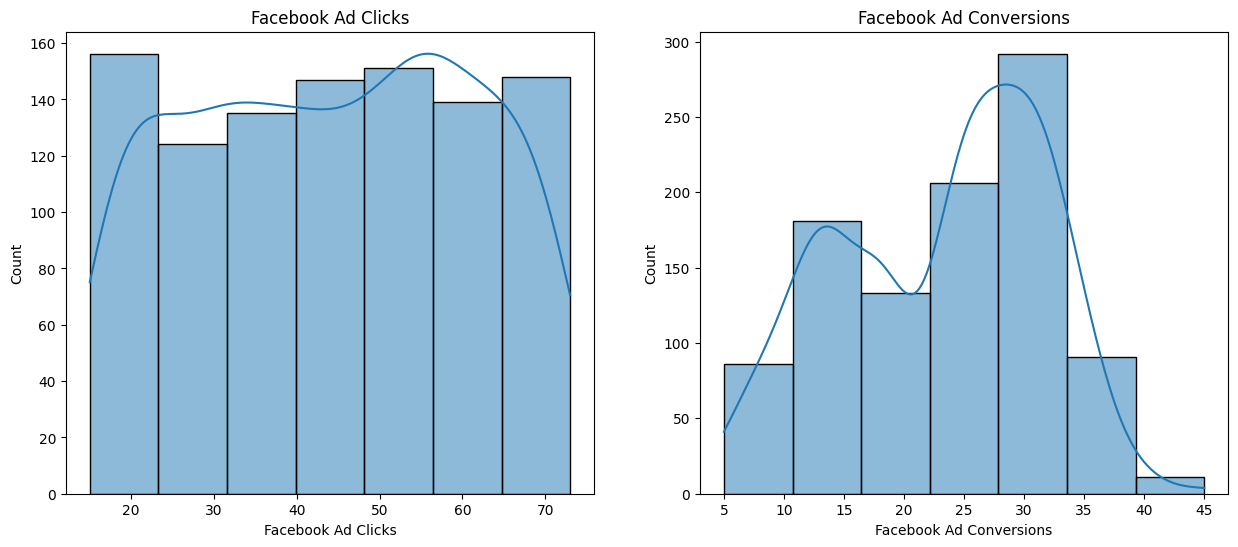

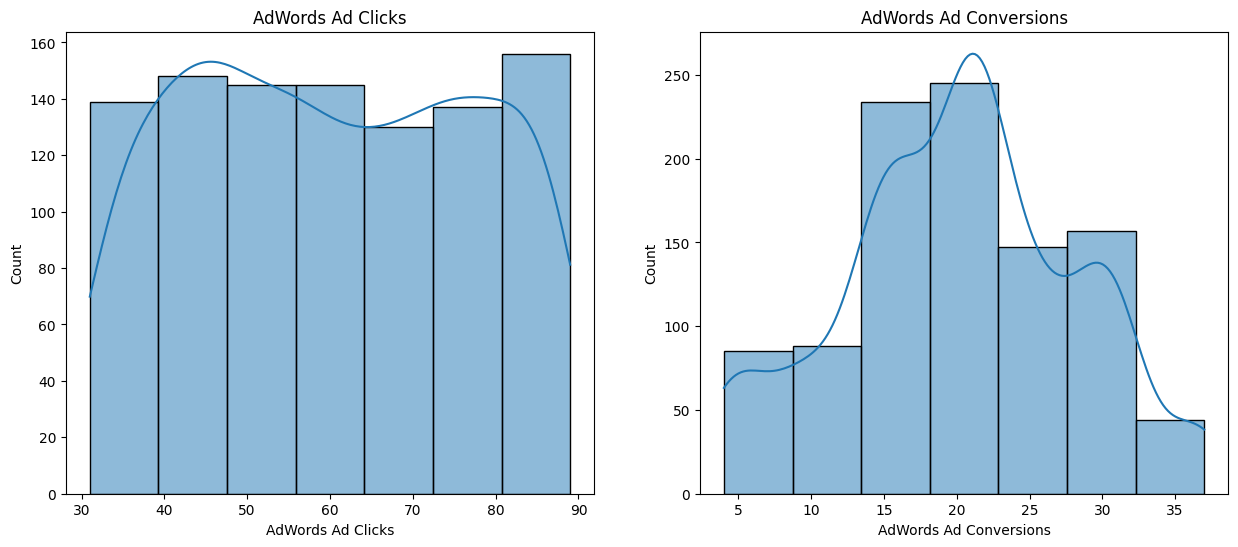

In [174]:
# distribution of the clicks and conversions
plt.figure(figsize=(15,6))
plt.subplot(1,2,1)
plt.title('Facebook Ad Clicks')
sns.histplot(df['Facebook Ad Clicks'], bins = 7, edgecolor = 'k', kde = True)

plt.subplot(1,2,2)
plt.title('Facebook Ad Conversions')
sns.histplot(df['Facebook Ad Conversions'], bins = 7, edgecolor = 'k', kde = True)
plt.show()

plt.figure(figsize=(15,6))
plt.subplot(1,2,1)
plt.title('AdWords Ad Clicks')
sns.histplot(df['AdWords Ad Clicks'], bins = 7, edgecolor = 'k', kde = True)

plt.subplot(1,2,2)
plt.title('AdWords Ad Conversions')
sns.histplot(df['AdWords Ad Conversions'], bins = 7, edgecolor = 'k', kde = True)
plt.show()


The histograms indicate that the distribution of clicks and conversions for both Facebook and AdWords ads is relatively balanced around the central values, with no strong skewness. Most observations fall within the mid-range, suggesting a consistent pattern in advertising performance without extreme outliers.

**How frequently do we observe days with high numbers of conversions compared to days with low numbers of conversions?**

In [175]:
# creating function to calculate the category for the conversions
def create_conversion_category(conversion_col):
    category = []
    for conversion in df[conversion_col]:
        if conversion < 6:
            category.append('less than 6')
        elif 6 <= conversion < 11:
            category.append('6 - 10')
        elif 11 <= conversion < 16:
            category.append('10 - 15')
        else:
            category.append('more than 15')
    return category

# applying function of different campaign's conversions
df['Facebook Conversion Category'] = create_conversion_category('Facebook Ad Conversions')
df['AdWords Conversion Category'] = create_conversion_category('AdWords Ad Conversions')

In [176]:
df[['Facebook Ad Conversions', 'Facebook Conversion Category', 'AdWords Ad Conversions', 'AdWords Conversion Category']].head()

,Facebook Ad Conversions,Facebook Conversion Category,AdWords Ad Conversions,AdWords Conversion Category
0,33,more than 15,16,more than 15
1,30,more than 15,18,more than 15
2,28,more than 15,18,more than 15
3,11,10 - 15,17,more than 15
4,5,less than 6,14,10 - 15


In [177]:
df['Facebook Conversion Category'].value_counts()

Facebook Conversion Category
more than 15    747
10 - 15         167
6 - 10           74
less than 6      12
Name: count, dtype: int64

In [178]:
facebook = pd.DataFrame(df['Facebook Conversion Category'].value_counts()).reset_index().rename(columns = {'Facebook Conversion Category':'Category'})
facebook

,Category,count
0,more than 15,747
1,10 - 15,167
2,6 - 10,74
3,less than 6,12


In [179]:
df['AdWords Conversion Category'].value_counts()

AdWords Conversion Category
more than 15    728
10 - 15         144
6 - 10           67
less than 6      61
Name: count, dtype: int64

In [180]:
# Creating the adwords dataframe
adwords = pd.DataFrame(df['AdWords Conversion Category'].value_counts()).reset_index().rename(columns = {'AdWords Conversion Category':'Category'})
adwords

,Category,count
0,more than 15,728
1,10 - 15,144
2,6 - 10,67
3,less than 6,61


In [181]:
# Merging the facebook and adwords dataframes
category_df = pd.merge(facebook, adwords, on = 'Category', how = 'outer').fillna(0)
category_df

,Category,count_x,count_y
0,10 - 15,167,144
1,6 - 10,74,67
2,less than 6,12,61
3,more than 15,747,728


In [182]:
# Reordering the rows for better visualization
category_df = category_df.iloc[[3,1,0,2]]
category_df

,Category,count_x,count_y
3,more than 15,747,728
1,6 - 10,74,67
0,10 - 15,167,144
2,less than 6,12,61


In [183]:
# Reordering the rows to ensure categories are in logical order
category_df = category_df.iloc[[3, 1, 0, 2]]
category_df

,Category,count_x,count_y
2,less than 6,12,61
1,6 - 10,74,67
3,more than 15,747,728
0,10 - 15,167,144


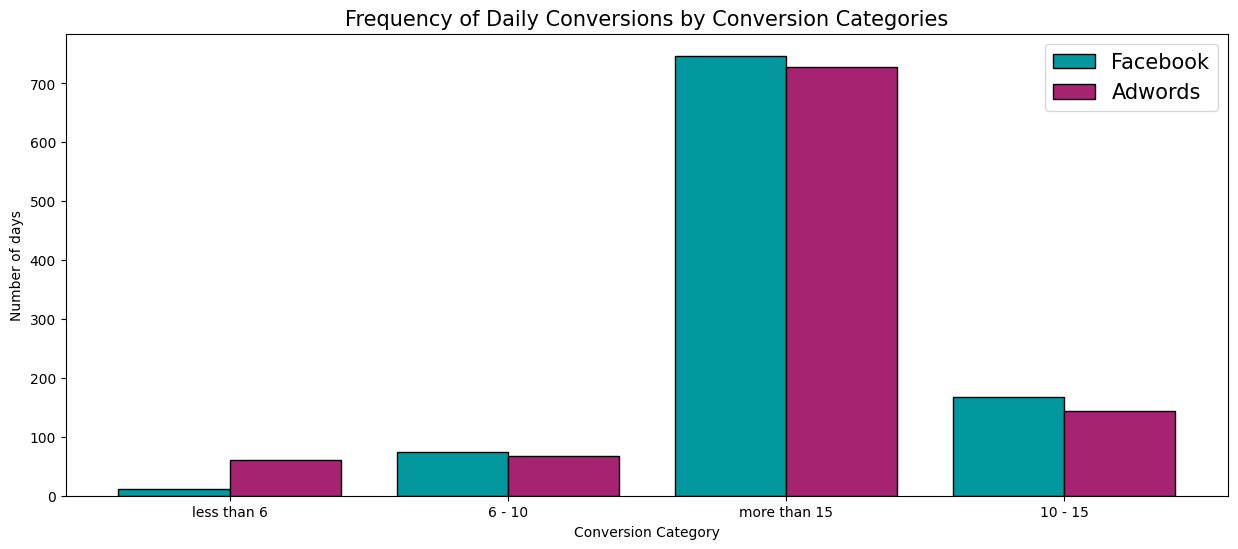

In [184]:
# Setting up the X-axis positions
X_axis = np.arange(len(category_df))

# Plotting the data
plt.figure(figsize = (15, 6))

# Creating the bars for Facebook and Adwords
plt.bar(X_axis - 0.2, category_df['count_x'], 0.4, label = 'Facebook', color = '#03989E', linewidth = 1, edgecolor = 'k')
plt.bar(X_axis + 0.2, category_df['count_y'], 0.4, label = 'Adwords', color = '#A62372', linewidth = 1, edgecolor = 'k')

# Adding labels and titles
plt.xticks(X_axis, category_df['Category'])
plt.xlabel("Conversion Category")
plt.ylabel("Number of days")
plt.title("Frequency of Daily Conversions by Conversion Categories", fontsize = 15)
plt.legend(fontsize = 15)

plt.show()

- The data suggests Facebook had more frequent higher conversion days than AdWords, which either had very low conversion rates (less than 6) or moderate ones (6 - 10).
- There is a significant variance in the number of high-conversion days between two different campaigns.
- The absence of any days with conversions between 10 - 15 and more than 15 in AdWords indicates a need to review what strategies were changed or what external factors could have influenced these numbers.


### Do more clicks on the ad really lead to more sales?


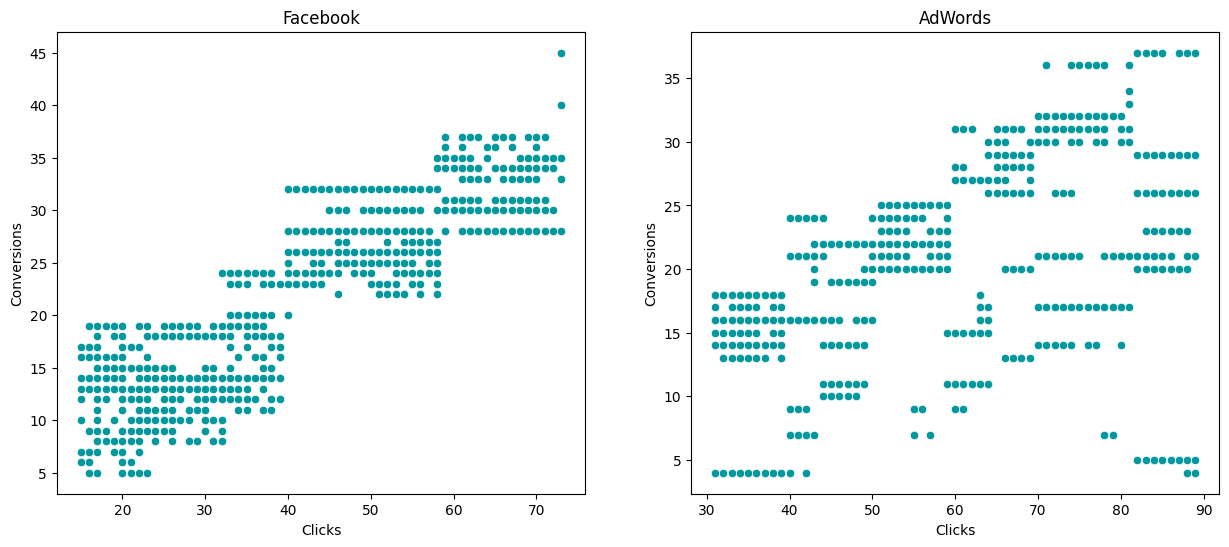

In [185]:
plt.figure(figsize=(15,6))
plt.subplot(1,2,1)
plt.title('Facebook')
sns.scatterplot(x = df['Facebook Ad Clicks'],y = df['Facebook Ad Conversions'], color = '#03989E')
plt.xlabel('Clicks')
plt.ylabel('Conversions')

plt.subplot(1,2,2)
plt.title('AdWords')
sns.scatterplot(x = df['AdWords Ad Clicks'],y = df['AdWords Ad Conversions'], color ='#03989E')
plt.xlabel('Clicks')
plt.ylabel('Conversions')

plt.show()


In [186]:
# Calculating correlation Co-efficient for Facebook
facebook_corr = df[['Facebook Ad Conversions', 'Facebook Ad Clicks']].corr()
facebook_corr

,Facebook Ad Conversions,Facebook Ad Clicks
Facebook Ad Conversions,1.000000,0.873078
Facebook Ad Clicks,0.873078,1.000000


In [187]:
# Calculating correlation Co-efficient for AdWords
adwords_corr = df[['AdWords Ad Conversions', 'AdWords Ad Clicks']].corr()
adwords_corr

,AdWords Ad Conversions,AdWords Ad Clicks
AdWords Ad Conversions,1.000000,0.417985
AdWords Ad Clicks,0.417985,1.000000


In [188]:
# Printing the formatted output
print('Correlation Coeff \n-----------------')
print('Facebook :', round(facebook_corr.values[0,1], 2))
print('AdWords  :', round(adwords_corr.values[0,1], 2))

Correlation Coeff 
-----------------
Facebook : 0.87
AdWords  : 0.42


- A correlation coefficient of 0.87 indicates a strong positive linear relationship between clicks on Facebook ads and sales, suggesting that increased clicks tend to drive higher sales.
- This strong relationship indicates that Facebook ads are highly effective for driving sales, with a significant portion of sales variation explained by ad clicks.
- The high correlation implies that increasing investment or optimizing Facebook ads could further boost sales performance.
- A correlation coefficient of 0.42 shows a moderate positive relationship between AdWords clicks and sales, which is weaker than that of Facebook ads.
- The moderate correlation for AdWords suggests it contributes to sales but is influenced by other factors, requiring further analysis to optimize campaigns.

## Hypothesis Testing

**Hypothesis:** Advertising on Facebook will result in a greater number of conversions compared to advertising on AdWords.

**Null Hypothesis ():** There is no difference in the number of conversions between Facebook and AdWords, or the number of conversions from AdWords is greater than or equal to those from Facebook.

H0: mu_Facebook <= mu_AdWords

**Alternate Hypothesis ():** The number of conversions from Facebook is greater than the number of conversions from AdWords.

H1: mu_Facebook > mu_AdWords


In [189]:
print('Mean Conversion \n-----------------')
print('Facebook : ', round(df['Facebook Ad Conversions'].mean(),2))
print('Adwords  : ', round(df['AdWords Ad Conversions'].mean(),2))

t_stats, p_value = st.ttest_ind(a = df['Facebook Ad Conversions'], b = df['AdWords Ad Conversions'], equal_var = False)
print('\nT statistic', t_stats, '\np-value',p_value)

# comparing the p value with the significance of 5% or 0.05
if p_value < 0.05:
    print("\np-value is less than significance value, Reject the null hypothesis")
else:
    print("\np-value is greater than significance value, Accept the null hypothesis")


Mean Conversion 
-----------------
Facebook :  23.16
Adwords  :  20.17

T statistic 8.055819692056104 
p-value 1.3472113851828173e-15

p-value is less than significance value, Reject the null hypothesis


- The average number of conversions from Facebook ads (23.16) is higher than that from AdWords ads (20.17), suggesting that Facebook campaigns generate slightly more conversions on average.

- The independent t-test produced a T-statistic of 8.06, indicating a substantial difference between the two groups relative to the variability in the data.

- The p-value (1.35 × 10⁻¹⁵) is extremely small and far below the 0.05 significance level, providing strong evidence to reject the null hypothesis.

- This result indicates that the difference in conversions between Facebook and AdWords advertising is statistically significant.

- From a marketing perspective, Facebook advertising appears to be a more effective channel for generating conversions compared to AdWords based on the analyzed dataset.

### Business Recommendation

Given the statistically significant difference in conversion performance, marketers may consider allocating more resources to Facebook advertising, while still monitoring AdWords performance and optimizing campaign strategies across both platforms.

## Regression Analysis
What will happen when I do go with the Facebook Ad? How many facebook ad conversions can I expect given a certain number of facebook ad clicks?

In [190]:
# independent variable
X = df[['Facebook Ad Clicks']]

# dependent variable
y = df[['Facebook Ad Conversions']]

# initializing and fitting Linear Regression model
reg_model = LinearRegression()
reg_model.fit(X,y)
prediction = reg_model.predict(X)

# model evaluation
r2 = r2_score(y, prediction)*100
mse = mean_squared_error(y, prediction)
print('Accuracy (R2 Score):',round(r2,2),'%')
print('Mean Squared Error:', round(mse,2))


Accuracy (R2 Score): 76.23 %
Mean Squared Error: 17.53


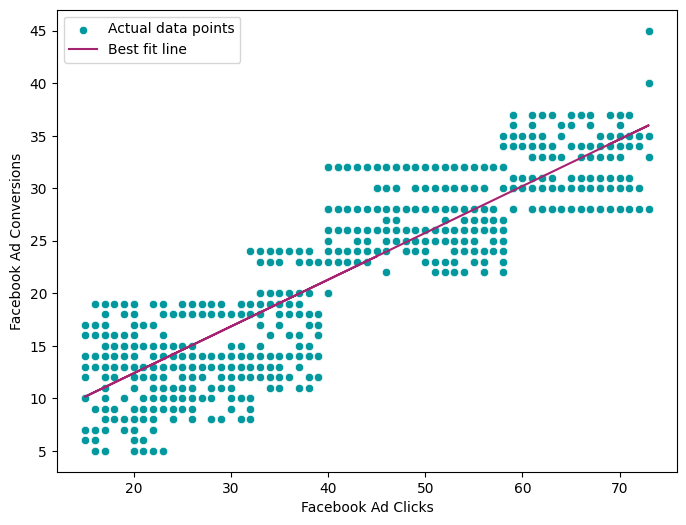

In [191]:
plt.figure(figsize=(8,6))
sns.scatterplot(x = df['Facebook Ad Clicks'], y = df['Facebook Ad Conversions'], color = '#03989E', label = 'Actual data points')
plt.plot(df['Facebook Ad Clicks'], prediction, color = '#A62372', label = 'Best fit line')
plt.legend()
plt.show()


In [192]:

print(f'For (50) Clicks, Expected Conversion : {round(reg_model.predict([[50]])[0][0],2)}')
print(f'For (80) Clicks, Expected Conversion : {round(reg_model.predict([[80]])[0][0],2)}')


For (50) Clicks, Expected Conversion : 25.74
For (80) Clicks, Expected Conversion : 39.11


- The model has a reasonably good predictive power, with an R2 score of 76.23%. This suggests that it can effectively predict Facebook ad conversions based on the number of Facebook ad clicks.
- With the insights provided by the Linear Regression model, businesses can make informed decisions about resource allocation, budget planning, and campaign optimization.
- For instance, knowing the expected number of Facebook ad conversions based on a certain number of Facebook ad clicks can help in setting realistic campaign goals, optimizing ad spend, and assessing the ROI of Facebook advertising efforts.

In [193]:
# cleaning data ( removing unwanted symbols from the columns and converting them to numerical columns)
df['Facebook Click-Through Rate (Clicks / View)'] = df['Facebook Click-Through Rate (Clicks / View)'].apply(lambda x: float(x[:-1]))
df['Facebook Conversion Rate (Conversions / Clicks)'] = df['Facebook Conversion Rate (Conversions / Clicks)'].apply(lambda x: float(x[:-1]))
df['Facebook Cost per Click (Ad Cost / Clicks)'] = df['Facebook Cost per Click (Ad Cost / Clicks)'].apply(lambda x: float(x[1:]))
df['Facebook Cost Per Ad'] = df['Facebook Cost Per Ad'].apply(lambda x: float(x[1:]))

In [194]:
# filtering for facebook campaign
df = df[['Date', 'Facebook Ad Views',
    'Facebook Ad Clicks', 'Facebook Ad Conversions', 'Facebook Cost Per Ad',
    'Facebook Click-Through Rate (Clicks / View)',
    'Facebook Conversion Rate (Conversions / Clicks)',
    'Facebook Cost per Click (Ad Cost / Clicks)']]

In [195]:
# extracting month and week day from the date column
df['month'] = df['Date'].dt.month
df['week'] = df['Date'].dt.weekday

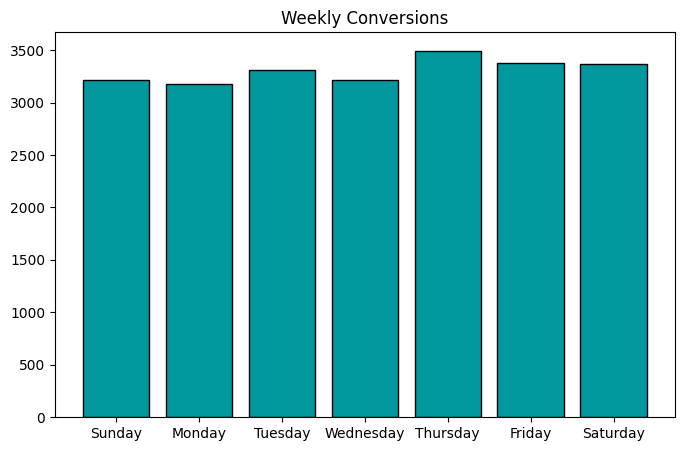

In [ ]:
plt.figure(figsize=(8,5))
plt.title('Weekly Conversions')
weekly_conversion = df.groupby('week')['Facebook Ad Conversions'].sum()
week_names = ['Sunday', 'Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday']
plt.bar(week_names, weekly_conversion, color = '#03989E', edgecolor = 'k')
plt.show()

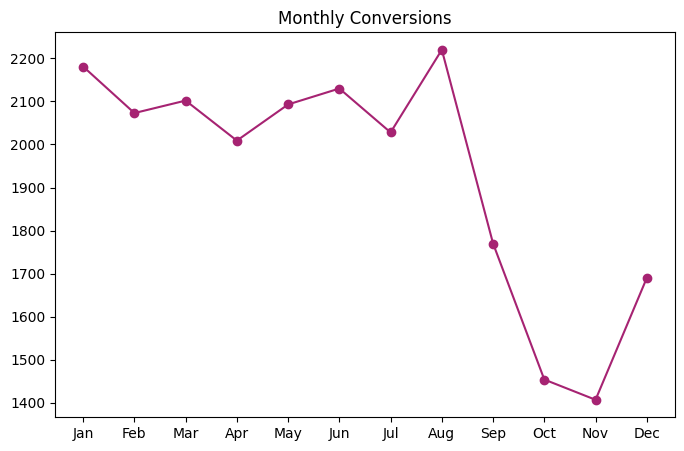

In [199]:
plt.figure(figsize=(8,5))
plt.title('Monthly Conversions')
# ERROR SOURCE IS IN THE LINE BELOW:
monthly_conversion = df.groupby('month')[['Facebook Ad Conversions']].sum()
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
plt.plot(month_names, monthly_conversion['Facebook Ad Conversions'], '-o', color = '#A62372')
plt.show()

- While the total number of conversions remains relatively consistent throughout the year, Mondays and Tuesdays consistently exhibit the highest rates, indicating heightened user engagement at the beginning of the workweek.
- The overall trend shows an upward trajectory in conversions over the year; however,, dips are observed in February, April, May, June, August, and November, which may be due to seasonal fluctuations or marketing strategy adjustments.

## How does the Cost Per Conversion (CPC) trend over time?
Cost Per Conversion (CPC): This metric is used to evaluate the cost effectiveness and profitability of an online advertising campaign. This metric helps marketers understand how much they are spending to obtain each conversion, allowing them to optimize their spending and targeting strategies effectively.


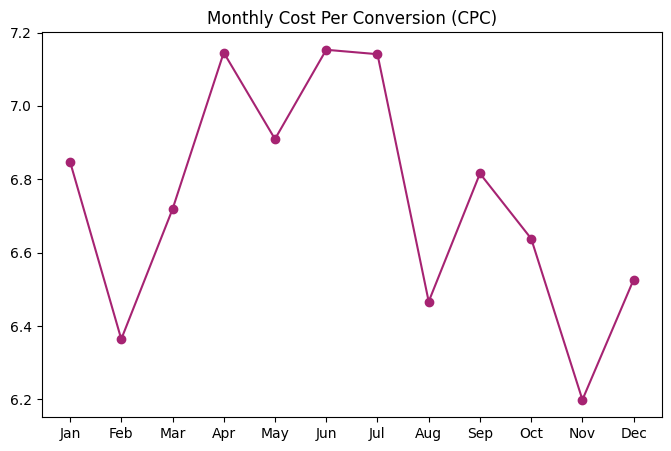

In [201]:
plt.figure(figsize=(8,5))
plt.title('Monthly Cost Per Conversion (CPC)')
monthly_df = df.groupby('month')[['Facebook Ad Conversions','Facebook Cost Per Ad']].sum()
monthly_df['Cost per Conversion'] = monthly_df['Facebook Cost Per Ad'] / monthly_df['Facebook Ad Conversions']
plt.plot(month_names, monthly_df['Cost per Conversion'], '-o', color = '#A62372')
plt.show()

- **Stable Range:** The CPC trend over the 12-month period shows fluctuations but generally stays between 6.2 and 7.2.
- **Lowest CPC Values:** November and February have the lowest CPC values (approx. 6.2 and 6.35, respectively). This indicates more cost-effective advertising or higher conversion efficiency during these periods.
- **Highest CPC Values:** June, July, and April show the highest CPC values (peaking near 7.15). This suggests advertising costs are relatively higher or conversion rates are lower during these summer months.
- **Strategic Allocation:** Lower CPC values in November and February indicate periods of high advertising effectiveness.
- **ROI Optimization:** Consider shifting more budget toward November and February to take advantage of the lower costs and maximize ROI.

**Research Question**

- **Is there a long-term equilibrium relationship between advertising spend and conversion rates that suggests a stable, proportional impact of budget changes on conversions over time?**

In [203]:
score, p_value, _ = coint(df['Facebook Cost Per Ad'], df['Facebook Ad Conversions'])
print('Cointegration test score:', score)
print('P-value:', p_value)

if p_value < 0.05:
    print("\np-value is less than significance value, Reject the null hypothesis")
else:
    print("\np-value is greater than significance value, Accept the null hypothesis")

Cointegration test score: -30.914109287546392
P-value: 0.0

p-value is less than significance value, Reject the null hypothesis


- Since the p-value is significantly lower than the chosen significance level, we reject the null hypothesis. This indicates that there is a long-term equilibrium relationship between advertising spend (cost) and conversions.

- Businesses can use this understanding of the stable relationship between cost and conversions to optimize their advertising strategies. By investing in campaigns that demonstrate a strong return on investment (ROI) and adjusting spending based on performance, companies can maximize conversions while minimizing costs.